In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/lfwpeople/pairsDevTrain.txt
/kaggle/input/lfwpeople/lfw-funneled.tgz
/kaggle/input/lfwpeople/pairsDevTest.txt
/kaggle/input/lfwpeople/pairs.txt


# Data Loading and Exploration

In [ ]:
import os
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
base_path = "/kaggle/input/lfwpeople"

print("Files in dataset directory:")
for f in os.listdir(base_path):
    print(f)

Files in dataset directory:
pairsDevTrain.txt
lfw-funneled.tgz
pairsDevTest.txt
pairs.txt


In [ ]:
tgz_path = "/kaggle/input/lfwpeople/lfw-funneled.tgz"
extract_root = "/kaggle/working"

with tarfile.open(tgz_path, "r:gz") as tar:
    tar.extractall(path=extract_root)

print("Extraction completed.")
print("Files in /kaggle/working:", os.listdir(extract_root))

/tmp/ipykernel_55/346791743.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_root)


Extraction completed.
Files in /kaggle/working: ['.virtual_documents', 'lfw_funneled']


In [ ]:
image_dir = "/kaggle/working/lfw_funneled"

print("Number of people folders:", len(os.listdir(image_dir)))
print("Sample people:", os.listdir(image_dir)[:5])

Number of people folders: 5760
Sample people: ['James_Coburn', 'Todd_MacCulloch', 'Sean_Penn', 'Jose_Rosado', 'Zeljko_Rebraca']


In [ ]:
total_images = 0
people_count = 0

for item in os.listdir(image_dir):
    item_path = os.path.join(image_dir, item)

    if os.path.isdir(item_path):   # 🔑 this line fixes everything
        people_count += 1
        total_images += len(os.listdir(item_path))

print("Total people:", people_count)
print("Total images:", total_images)

Total people: 5749
Total images: 13233


In [ ]:
print("Non-directory files in lfw_funneled:")
for item in os.listdir(image_dir):
    if not os.path.isdir(os.path.join(image_dir, item)):
        print(item)

Non-directory files in lfw_funneled:
pairs_02.txt
pairs_06.txt
pairs_04.txt
pairs_01.txt
pairs_10.txt
pairs_07.txt
pairs.txt
pairs_05.txt
pairs_09.txt
pairs_03.txt
pairs_08.txt


# Exploratory Data Analysis

In [ ]:
data = []

for person in os.listdir(image_dir):
    person_path = os.path.join(image_dir, person)
    if os.path.isdir(person_path):
        img_count = len(os.listdir(person_path))
        data.append([person, img_count])

df_counts = pd.DataFrame(data, columns=["person", "image_count"])

df_counts

,person,image_count
0,James_Coburn,1
1,Todd_MacCulloch,1
2,Sean_Penn,3
3,Jose_Rosado,1
4,Zeljko_Rebraca,1
...,...,...
5744,Steve_Wariner,1
5745,Mike_Bair,1
5746,Gong_Ruina,1
5747,Juergen_Schrempp,1


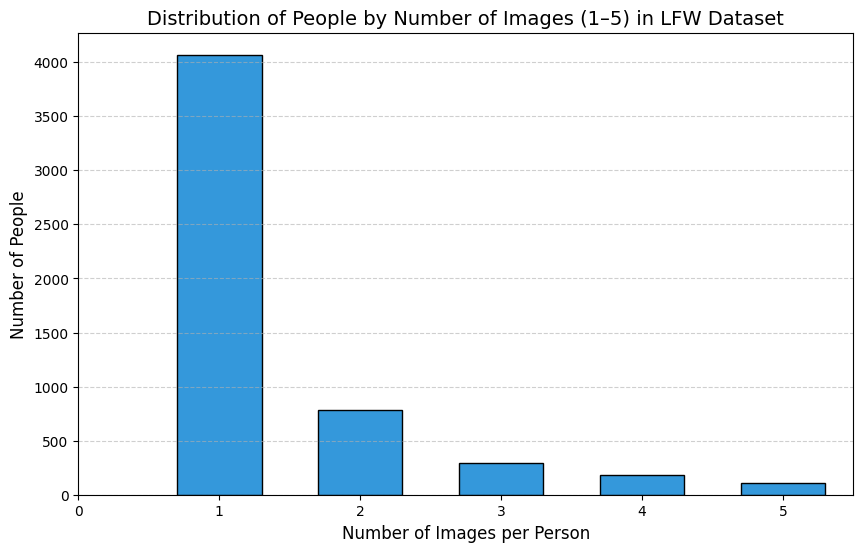

In [ ]:
image_count_freq = (
    df_counts["image_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

image_count_freq.columns = ["num_images", "num_people"]

# Keep only image counts from 1 to 5
plot_data = image_count_freq[image_count_freq["num_images"].between(1, 5)]

plt.figure(figsize=(10,6))

plt.bar(
    plot_data["num_images"],
    plot_data["num_people"],
    color="#3498DB",
    edgecolor="black",
    width=0.6
)

plt.title("Distribution of People by Number of Images (1–5) in LFW Dataset", fontsize=14)
plt.xlabel("Number of Images per Person", fontsize=12)
plt.ylabel("Number of People", fontsize=12)

# Force x-axis scale from 0 to 5
plt.xticks([0, 1, 2, 3, 4, 5])
plt.xlim(0, 5.5)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


In [ ]:
df_counts["image_count"].describe()

count    5749.000000
mean        2.301792
std         9.016410
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       530.000000
Name: image_count, dtype: float64

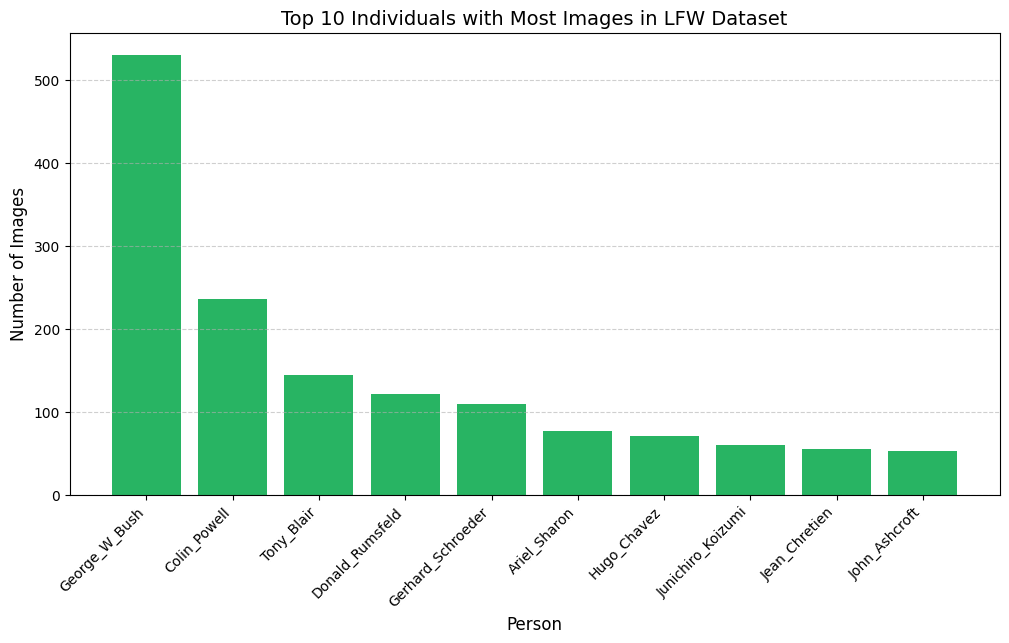

In [ ]:
# Top 10 People with Most Images

top_10 = df_counts.sort_values("image_count", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_10["person"],
        top_10["image_count"],
        color="#28B463")

plt.title("Top 10 Individuals with Most Images in LFW Dataset", fontsize=14)
plt.xlabel("Person", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

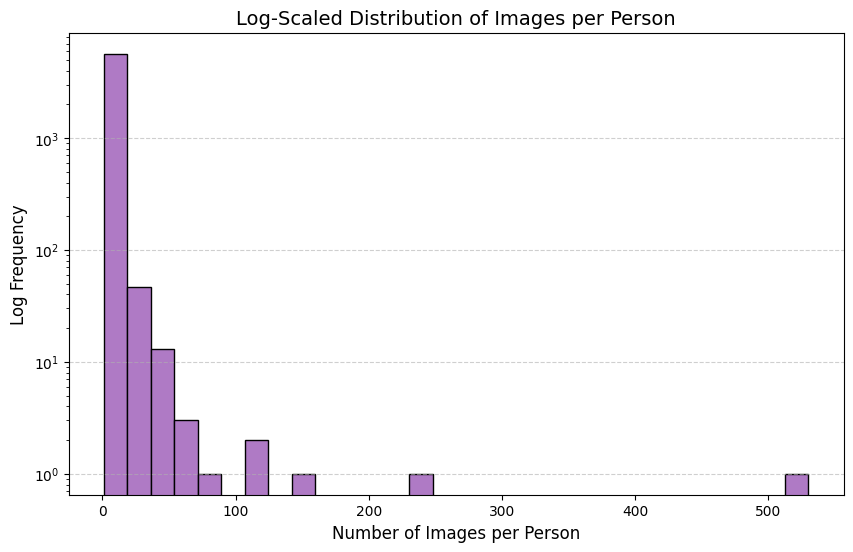

In [ ]:
# Log-Scale Distribution

plt.figure(figsize=(10,6))
plt.hist(df_counts["image_count"],
         bins=30,
         log=True,
         color="#AF7AC5",
         edgecolor="black")

plt.title("Log-Scaled Distribution of Images per Person", fontsize=14)
plt.xlabel("Number of Images per Person", fontsize=12)
plt.ylabel("Log Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

**YuNet + GhostFaceNet Face Recognition**

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm

import tarfile
import random

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.8.0+cu126
CUDA available: True
Using device: cuda


In [ ]:
print("\n=== Downloading YuNet Model ===")
yunet_model_path = "face_detection_yunet_2023mar.onnx"

if not os.path.exists(yunet_model_path):
    !wget https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx
    print("YuNet model downloaded successfully!")
else:
    print("YuNet model already exists!")


=== Downloading YuNet Model ===
--2025-12-24 17:50:07--  https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/opencv/opencv_zoo/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx [following]
--2025-12-24 17:50:07--  https://media.githubusercontent.com/media/opencv/opencv_zoo/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 232589 (227K) [application/octet-stream]
Saving to: ‘face_detection_yunet_2

Extract and Prepare LFW Dataset

In [ ]:
# Path to the compressed dataset
lfw_tgz_path = "/kaggle/input/lfwpeople/lfw-funneled.tgz"
extract_dir = "/kaggle/working/lfw-funneled"

# Extract if not already done
if not os.path.exists(extract_dir):
    print("Extracting lfw-funneled.tgz ...")
    with tarfile.open(lfw_tgz_path, "r:gz") as tar:
        tar.extractall(path=extract_dir)
    print(f"Extracted to: {extract_dir}")
else:
    print(f"Already extracted at: {extract_dir}")

# The folder inside the tarball is usually named "lfw_funneled"
lfw_path = os.path.join(extract_dir, "lfw_funneled")


if not os.path.exists(lfw_path):
    # fallback: sometimes folder name differs
    possible = [p for p in Path(extract_dir).iterdir() if p.is_dir()]
    if possible:
        lfw_path = str(possible[0])

print(f"Dataset path verified: {lfw_path}")
num_dirs = len([d for d in Path(lfw_path).iterdir() if d.is_dir()])
print(f"Number of person directories: {num_dirs}")

Extracting lfw-funneled.tgz ...
Extracted to: /kaggle/working/lfw-funneled
Dataset path verified: /kaggle/working/lfw-funneled/lfw_funneled
Number of person directories: 5749


In [ ]:
import cv2


class FaceDetector:
    """YuNet face detector wrapper"""
    def __init__(self, model_path, conf_threshold=0.6, nms_threshold=0.3):
        self.detector = cv2.FaceDetectorYN.create(
            model_path,
            "",
            (320, 320),
            conf_threshold,
            nms_threshold
        )

    def detect(self, image):
        """Detect faces in image and return bounding boxes"""
        h, w = image.shape[:2]
        self.detector.setInputSize((w, h))
        _, faces = self.detector.detect(image)
        return faces


def prepare_dataset(lfw_path, output_dir="processed_lfw", min_faces=20):
    """
    Process LFW dataset: detect faces and organize for training
    Only keep identities with at least min_faces images
    """
    face_detector = FaceDetector(yunet_model_path)
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)

    processed_data = []
    label_counts = {}

    # Count images per person
    for person_dir in Path(lfw_path).iterdir():
        if person_dir.is_dir():
            count = len(list(person_dir.glob("*.jpg")))
            if count >= min_faces:
                label_counts[person_dir.name] = count

    print(f"Found {len(label_counts)} identities with at least {min_faces} images")

    # Process each person's images
    for person_name in tqdm(label_counts.keys(), desc="Processing faces"):
        person_path = Path(lfw_path) / person_name
        person_output = output_path / person_name
        person_output.mkdir(exist_ok=True)

        for img_path in person_path.glob("*.jpg"):
            try:
                img = cv2.imread(str(img_path))
                if img is None:
                    continue
                    # Detect face
                faces = face_detector.detect(img)

                if faces is not None and len(faces) > 0:
                    # Get the first (and usually only) face
                    x, y, w, h = faces[0][:4].astype(int)

                    # Add margin and crop
                    margin = 0.2
                    x1 = max(0, int(x - w * margin))
                    y1 = max(0, int(y - h * margin))
                    x2 = min(img.shape[1], int(x + w * (1 + margin)))
                    y2 = min(img.shape[0], int(y + h * (1 + margin)))

                    face_img = img[y1:y2, x1:x2]

                    # Resize to 112x112 (standard for face recognition)
                    face_img = cv2.resize(face_img, (112, 112))

                    # Save processed face
                    output_file = person_output / img_path.name
                    cv2.imwrite(str(output_file), face_img)

                    processed_data.append({
                        'path': str(output_file),
                        'label': person_name
                    })
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue

    return processed_data

print("\n=== Processing LFW Dataset with YuNet ===")
processed_data = prepare_dataset(lfw_path, min_faces=20)
print(f"Total processed images: {len(processed_data)}")


=== Processing LFW Dataset with YuNet ===
Found 62 identities with at least 20 images


Processing faces: 100%|██████████| 62/62 [00:16<00:00,  3.66it/s]

Total processed images: 3023


Split Dataset

In [ ]:
print("\n Splitting Dataset ")

# Extract labels
labels = [item['label'] for item in processed_data]
unique_labels = list(set(labels))
print(f"Number of unique identities: {len(unique_labels)}")

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

# Split: 70% train, 15% val, 15% test
paths = [item['path'] for item in processed_data]
X_train, X_temp, y_train, y_temp = train_test_split(
    paths, encoded_labels, test_size=0.3, stratify=encoded_labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")


 Splitting Dataset 
Number of unique identities: 62
Train samples: 2116
Validation samples: 453
Test samples: 454


GhostFaceNet Architecture

In [ ]:
class GhostModule(nn.Module):
    """Ghost Module for efficient feature extraction"""
    def __init__(self, inp, oup, kernel_size=1, ratio=2, dw_size=3, stride=1, relu=True):
        super(GhostModule, self).__init__()
        self.oup = oup
        init_channels = oup // ratio
        new_channels = oup - init_channels

        self.primary_conv = nn.Sequential(
            nn.Conv2d(inp, init_channels, kernel_size, stride, kernel_size//2, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True) if relu else nn.Sequential(),
        )

        self.cheap_operation = nn.Sequential(
            nn.Conv2d(init_channels, new_channels, dw_size, 1, dw_size//2, groups=init_channels, bias=False),
            nn.BatchNorm2d(new_channels),
            nn.ReLU(inplace=True) if relu else nn.Sequential(),
        )

    def forward(self, x):
        x1 = self.primary_conv(x)
        x2 = self.cheap_operation(x1)
        out = torch.cat([x1, x2], dim=1)
        return out[:, :self.oup, :, :]



class GhostBottleneck(nn.Module):
    """Ghost Bottleneck block"""
    def __init__(self, inp, hidden_dim, oup, kernel_size, stride, use_se):
        super(GhostBottleneck, self).__init__()
        self.stride = stride
        self.use_shortcut = stride == 1 and inp == oup

        # Point-wise expansion
        self.ghost1 = GhostModule(inp, hidden_dim, kernel_size=1, relu=True)

        # Depth-wise convolution
        if self.stride > 1:
            self.conv_dw = nn.Conv2d(hidden_dim, hidden_dim, kernel_size, stride,
                                     (kernel_size-1)//2, groups=hidden_dim, bias=False)
            self.bn_dw = nn.BatchNorm2d(hidden_dim)

        # Squeeze-and-excitation
        if use_se:
            self.se = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Conv2d(hidden_dim, hidden_dim // 4, 1, bias=False),
                nn.ReLU(inplace=True),
                nn.Conv2d(hidden_dim // 4, hidden_dim, 1, bias=False),
                nn.Sigmoid()
            )
        else:
            self.se = None

        # Point-wise linear projection
        self.ghost2 = GhostModule(hidden_dim, oup, kernel_size=1, relu=False)

        # Shortcut
        if not self.use_shortcut:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inp, inp, kernel_size, stride, (kernel_size-1)//2, groups=inp, bias=False),
                nn.BatchNorm2d(inp),
                nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )

    def forward(self, x):
        residual = x

        # 1st ghost bottleneck
        x = self.ghost1(x)

        # Depth-wise convolution
        if self.stride > 1:
            x = self.conv_dw(x)
            x = self.bn_dw(x)

        # Squeeze-and-excitation
        if self.se is not None:
            x = x * self.se(x)

        # 2nd ghost bottleneck
        x = self.ghost2(x)

        if self.use_shortcut:
            return x + residual
        else:
            return x + self.shortcut(residual)


class GhostFaceNet(nn.Module):
    """GhostFaceNet for face recognition"""
    def __init__(self, num_classes, width_mult=1.0):
        super(GhostFaceNet, self).__init__()

        # Setting of inverted residual blocks
        self.cfgs = [
            # k, t, c, SE, s
            [3,  16,  16, 0, 1],
            [3,  48,  24, 0, 2],
            [3,  72,  24, 0, 1],
            [5,  72,  40, 1, 2],
            [5, 120,  40, 1, 1],
            [3, 240,  80, 0, 2],
            [3, 200,  80, 0, 1],
            [3, 184,  80, 0, 1],
            [3, 184,  80, 0, 1],
            [3, 480, 112, 1, 1],
            [3, 672, 112, 1, 1],
            [5, 672, 160, 1, 2],
            [5, 960, 160, 0, 1],
            [5, 960, 160, 1, 1],
            [5, 960, 160, 0, 1],
            [5, 960, 160, 1, 1]
        ]

        # Building first layer
        output_channel = int(16 * width_mult)
        self.conv_stem = nn.Conv2d(3, output_channel, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(output_channel)
        self.act1 = nn.ReLU(inplace=True)
        input_channel = output_channel

        # Building inverted residual blocks
        stages = []
        for k, exp_size, c, use_se, s in self.cfgs:
            output_channel = int(c * width_mult)
            hidden_channel = int(exp_size * width_mult)
            stages.append(GhostBottleneck(input_channel, hidden_channel, output_channel, k, s, use_se))
            input_channel = output_channel

        self.blocks = nn.Sequential(*stages)

        # Building last several layers
        output_channel = int(960 * width_mult)
        self.conv_head = nn.Conv2d(input_channel, output_channel, 1, 1, 0, bias=False)
        self.bn2 = nn.BatchNorm2d(output_channel)
        self.act2 = nn.ReLU(inplace=True)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.conv_final = nn.Conv2d(output_channel, 512, 1, 1, 0, bias=True)

        # Embedding and classifier
        self.embedding = nn.Linear(512, 512)
        self.bn3 = nn.BatchNorm1d(512)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.act1(self.bn1(self.conv_stem(x)))
        x = self.blocks(x)
        x = self.act2(self.bn2(self.conv_head(x)))
        x = self.global_pool(x)
        x = self.conv_final(x)
        x = x.view(x.size(0), -1)

        # Get embeddings
        embeddings = self.bn3(self.embedding(x))

        # Classification
        logits = self.classifier(embeddings)

        return embeddings, logits

Dataset and DataLoader

In [ ]:
class FaceDataset(Dataset):
    """Face Recognition Dataset"""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label

# Data augmentation and normalization
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create datasets
train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
val_dataset = FaceDataset(X_val, y_val, transform=val_transform)
test_dataset = FaceDataset(X_test, y_test, transform=val_transform)


# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\nDataLoaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


DataLoaders created:
Train batches: 67
Val batches: 15
Test batches: 15


Training

In [ ]:
# Initialize model
num_classes = len(unique_labels)
model = GhostFaceNet(num_classes=num_classes, width_mult=1.0).to(device)

print(f"\nModel initialized with {num_classes} classes")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss functions
criterion_ce = nn.CrossEntropyLoss()

# Optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


Model initialized with 62 classes
Total parameters: 3,453,254


In [ ]:
# Model Summary Preview
from torchsummary import summary

try:
    dummy_input = (3, 112, 112)  # typical input size for face models
    print("\n=== Model Summary ===")
    summary(model, input_size=dummy_input)
except Exception as e:
    print(f"Summary failed: {e}")

# Estimate model size
param_size = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
total_size_mb = (param_size + buffer_size) / 1024**2
print(f"\nModel size (approx): {total_size_mb:.2f} MB")


=== Model Summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 56, 56]             432
       BatchNorm2d-2           [-1, 16, 56, 56]              32
              ReLU-3           [-1, 16, 56, 56]               0
            Conv2d-4            [-1, 8, 56, 56]             128
       BatchNorm2d-5            [-1, 8, 56, 56]              16
              ReLU-6            [-1, 8, 56, 56]               0
            Conv2d-7            [-1, 8, 56, 56]              72
       BatchNorm2d-8            [-1, 8, 56, 56]              16
              ReLU-9            [-1, 8, 56, 56]               0
      GhostModule-10           [-1, 16, 56, 56]               0
           Conv2d-11            [-1, 8, 56, 56]             128
      BatchNorm2d-12            [-1, 8, 56, 56]              16
           Conv2d-13            [-1, 8, 56, 56]              72
      BatchNorm2

Training and Validation

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        embeddings, logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': running_loss/total, 'acc': 100.*correct/total})

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        embeddings, logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': running_loss/total, 'acc': 100.*correct/total})

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

Training Loop

In [ ]:
def validate(model, loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)

            embeddings, logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item()
            _, predicted = logits.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [ ]:
num_epochs = 50
patience = 10
best_val_acc = 0.0
epochs_no_improve = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n=== Starting Training ===")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 50)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion_ce, optimizer, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion_ce, device)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Update learning rate
    scheduler.step()

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Check for improvement
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'label_encoder': label_encoder
        }, 'best_ghostfacenet.pth')
        print(f"✓ Saved best model with val_acc: {val_acc:.2f}%")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")

    # Early stopping
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered. No improvement for {patience} epochs.")
        break

print("\n=== Training Complete ===")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")


=== Starting Training ===

Epoch 1/50
--------------------------------------------------


Validation: 100%|██████████| 15/15 [00:00<00:00, 42.12it/s]


Train Loss: 1.1483, Train Acc: 66.21%
Val Loss: 1.5004, Val Acc: 61.37%
✓ Saved best model with val_acc: 61.37%

Epoch 2/50
--------------------------------------------------


Validation: 100%|██████████| 15/15 [00:00<00:00, 36.47it/s]


Train Loss: 1.0295, Train Acc: 69.05%
Val Loss: 1.3605, Val Acc: 64.02%
✓ Saved best model with val_acc: 64.02%

Epoch 3/50
--------------------------------------------------


...

Train Loss: 0.1854, Train Acc: 95.94%
Val Loss: 0.7306, Val Acc: 82.34%
No improvement for 8 epoch(s).

Epoch 22/50
--------------------------------------------------


Validation: 100%|██████████| 15/15 [00:00<00:00, 43.77it/s]


Train Loss: 0.1505, Train Acc: 97.16%
Val Loss: 0.7160, Val Acc: 82.56%
No improvement for 9 epoch(s).

Epoch 23/50
--------------------------------------------------


Validation: 100%|██████████| 15/15 [00:00<00:00, 40.87it/s]

Train Loss: 0.1040, Train Acc: 98.11%
Val Loss: 0.7048, Val Acc: 82.12%
No improvement for 10 epoch(s).

Early stopping triggered. No improvement for 10 epochs.

=== Training Complete ===
Best Validation Accuracy: 83.44%


Evaluation on Test Set

In [ ]:
print("\n Accuracy on Test Set")

# Load best model
checkpoint = torch.load('best_ghostfacenet.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc = validate(model, test_loader, criterion_ce, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")


 Accuracy on Test Set


Validation: 100%|██████████| 15/15 [00:00<00:00, 35.65it/s]

Test Loss: 0.7221
Test Accuracy: 82.38%


Curves

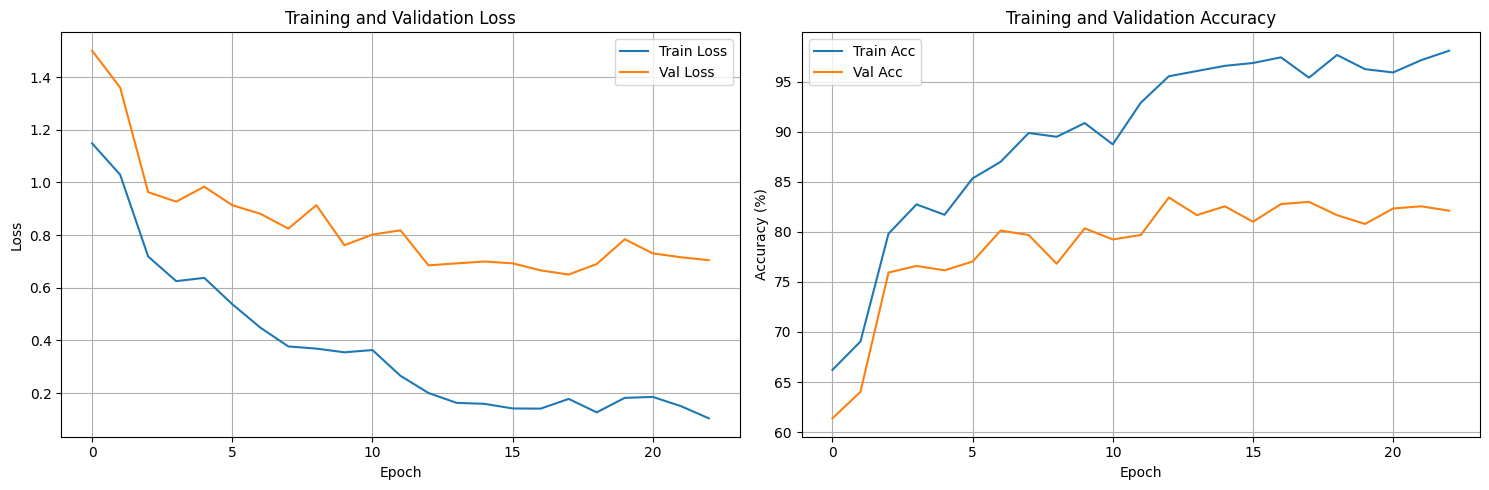

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

Saving best model

In [ ]:
# Load full checkpoint
checkpoint = torch.load("best_ghostfacenet.pth", map_location="cpu", weights_only=False)

# Extract model weights only (adjust key if needed)
if "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint  # already weights-only

# Save compact version
torch.save(state_dict, "ghostfacenet_weights_only.pth")

# Optional: verify size
size_mb = os.path.getsize("ghostfacenet_weights_only.pth") / 1024**2
print(f"Saved weights-only model: {size_mb:.2f} MB")

Saved weights-only model: 13.43 MB


Testing Examples

With Threshold od 70%

In [ ]:
def recognize_face(image_path, model, face_detector, label_encoder, device, threshold=0.7):
    """Recognize face in an image"""
    model.eval()

    # Load image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect face
    faces = face_detector.detect(img)

    if faces is None or len(faces) == 0:
        return None, "No face detected"

    # Process face
    x, y, w, h = faces[0][:4].astype(int)
    margin = 0.2
    x1 = max(0, int(x - w * margin))
    y1 = max(0, int(y - h * margin))
    x2 = min(img.shape[1], int(x + w * (1 + margin)))
    y2 = min(img.shape[0], int(y + h * (1 + margin)))

    face_img = img_rgb[y1:y2, x1:x2]
    face_img = cv2.resize(face_img, (112, 112))

    # Transform and predict
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    face_tensor = transform(face_img).unsqueeze(0).to(device)

    with torch.no_grad():
        embeddings, logits = model(face_tensor)
        probs = F.softmax(logits, dim=1)
        confidence, predicted = probs.max(1)

    if confidence.item() < threshold:
        return None, f"Unknown (confidence: {confidence.item():.2f})"

    person_name = label_encoder.inverse_transform([predicted.item()])[0]
    return person_name, f"Confidence: {confidence.item():.2f}"

# Test on a few samples
print("\n Testing Inference ")
face_detector = FaceDetector(yunet_model_path)

for img_path, y_true in random.sample(list(zip(X_test, y_test)), k=min(10, len(X_test))):
    true_label = label_encoder.inverse_transform([y_true])[0]
    pred_name, info = recognize_face(img_path, model, face_detector, label_encoder, device)
    print(f"True: {true_label} | Predicted: {pred_name} | {info}")


 Testing Inference 
True: Gerhard_Schroeder | Predicted: Gerhard_Schroeder | Confidence: 1.00
True: Ariel_Sharon | Predicted: Ariel_Sharon | Confidence: 1.00
True: Jennifer_Lopez | Predicted: Jennifer_Lopez | Confidence: 0.97
True: John_Negroponte | Predicted: John_Negroponte | Confidence: 0.89
True: Nestor_Kirchner | Predicted: Nestor_Kirchner | Confidence: 0.90
True: George_W_Bush | Predicted: George_W_Bush | Confidence: 0.93
True: Atal_Bihari_Vajpayee | Predicted: None | Unknown (confidence: 0.37)
True: Colin_Powell | Predicted: Colin_Powell | Confidence: 1.00
True: George_W_Bush | Predicted: George_W_Bush | Confidence: 1.00
True: Ariel_Sharon | Predicted: Ariel_Sharon | Confidence: 0.98


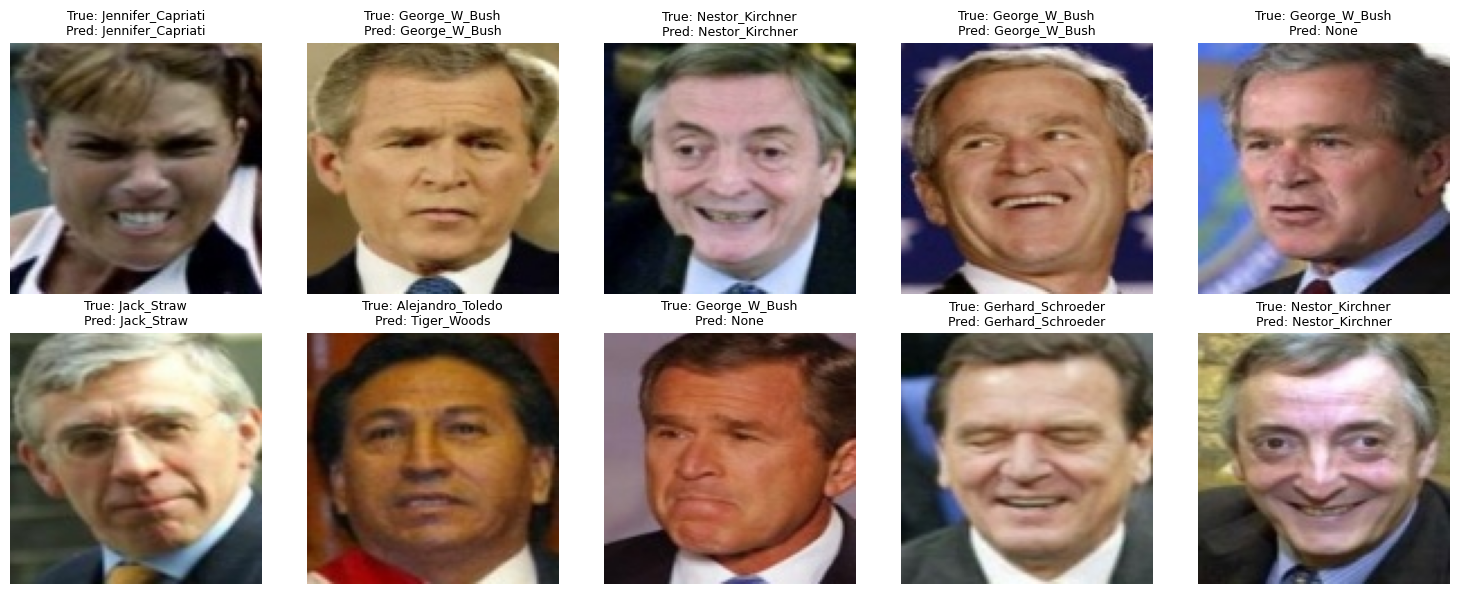

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import math

# Pick random samples
n_samples = min(10, len(X_test))  # adjust total samples shown
samples = random.sample(list(zip(X_test, y_test)), k=n_samples)

cols = 5
rows = math.ceil(n_samples / cols)

plt.figure(figsize=(15, 3 * rows))

for i, (img_path, y_true) in enumerate(samples):
    true_label = label_encoder.inverse_transform([y_true])[0]
    pred_name, info = recognize_face(img_path, model, face_detector, label_encoder, device)

    img = Image.open(img_path).convert("RGB")

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {true_label}\nPred: {pred_name}", fontsize=9)

plt.tight_layout()
plt.show()